# sklearn model with tensorflow keras tuner

In [1]:
import sklearn
print(sklearn.__version__)

1.2.2


In [2]:
import re
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
from textstat import flesch_reading_ease, gunning_fog
import numpy as np

# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('stopwords')
# nltk.download('vader_lexicon')

def extract_and_aggregate_features(df, text_column):
    """Extracts and aggregates features at the paragraph, sentence, and word levels."""
    # Processing text into paragraphs, sentences, and words
    df['paragraph_lengths'] = df[text_column].apply(lambda x: [len(p.split()) for p in x.split('\n\n') if p.strip()])
    df['sentence_lengths'] = df[text_column].apply(lambda x: [len(s.split()) for s in nltk.sent_tokenize(x)])
    df['word_lengths'] = df[text_column].apply(lambda x: [len(w) for w in x.split()])

    # Aggregating features
    df['paragraph_count'] = df['paragraph_lengths'].apply(len)
    df['sentence_count'] = df['sentence_lengths'].apply(len)
    df['word_count'] = df['word_lengths'].apply(len)

    df['avg_paragraph_length'] = df['paragraph_lengths'].apply(np.mean)
    df['max_paragraph_length'] = df['paragraph_lengths'].apply(max)
    df['min_paragraph_length'] = df['paragraph_lengths'].apply(min)

    df['avg_sentence_length'] = df['sentence_lengths'].apply(np.mean)
    df['max_sentence_length'] = df['sentence_lengths'].apply(max)
    df['min_sentence_length'] = df['sentence_lengths'].apply(min)

    df['avg_word_length'] = df['word_lengths'].apply(np.mean)
    df['max_word_length'] = df['word_lengths'].apply(max)
    df['min_word_length'] = df['word_lengths'].apply(min)

    # Cleaning up DataFrame to remove list columns
    df.drop(['paragraph_lengths', 'sentence_lengths', 'word_lengths'], axis=1, inplace=True)

    return df

def compute_readability_and_sentiment(df, text_column):
    """Computes readability scores and sentiment analysis."""
    df['flesch_reading_ease'] = df[text_column].apply(flesch_reading_ease)
    df['gunning_fog_index'] = df[text_column].apply(gunning_fog)
    sia = SentimentIntensityAnalyzer()
    df['sentiment_score'] = df[text_column].apply(lambda x: sia.polarity_scores(x)['compound'])

    return df


def add_text_features(df, text_column):
    """Main function to aggregate all text processing and feature extraction steps."""
    tqdm.pandas(desc="Extracting and aggregating text features")
    df = extract_and_aggregate_features(df, text_column)
    df = compute_readability_and_sentiment(df, text_column)


    
    return df    

In [3]:

import wordninja
from nltk.corpus import words

# Load a set of valid English words from NLTK for verification (if needed)
word_list = set(words.words())

def segment_text(text, word_list=word_list):
    """
    Segments concatenated words using wordninja, verifying segmentation with an NLTK words list.

    Args:
    text (str): A string of concatenated words.
    word_list (set): A set containing valid words.

    Returns:
    str: Segmented text, or the original text if segmentation results in less common words.
    """
    segmented_words = wordninja.split(text)
    segmented_text = ' '.join(segmented_words)

    # Optional: verify if the original text is a valid word and if the segmented version introduces less common words
    if text in word_list and not all(word in word_list for word in segmented_words):
        return text
    else:
        return segmented_text



def apply_segmentation(df_chunk, text_col='clean_text'):
    """
    Applies text segmentation to the specified 'text' column of a DataFrame chunk using wordninja.

    Args:
    df_chunk (pd.DataFrame): DataFrame chunk containing a text column with concatenated words.

    Returns:
    pd.DataFrame: DataFrame chunk with a new column 'segmented_text' containing segmented text.
    """
    df_chunk['clean_text'] = df_chunk[text_col].apply(lambda x: segment_text(x))
    return df_chunk

In [4]:
def clean_text(df, col_name = 'full_text'):
    """
    Preprocesses text for both training and testing datasets. 
    Includes loading embeddings, building vocabularies, cleaning text among other things.
    
    :param summaries_train: DataFrame with the training data
    :param summaries_test: DataFrame with the testing data
    :param glove_path: path to the GloVe embedding
    :param paragram_path: path to the Paragram embedding
    :param wiki_news_path: path to the Wiki News embedding
    
    :return: Preprocessed DataFrame and list of out-of-vocab words
    """
    print("Starting text cleaning process. \n")

    
    # Lowercase all texts

    df['lowered'] = df[col_name].apply(lambda x: x.lower())

    
    
    def clean_spacing(text):
        
        # Remove spaces before punctuation
        text = re.sub(r'\s+([,.!?])', r'\1', text)

        # Ensure there is one space after punctuation
        text = re.sub(r'([,.!?])([^\s])', r'\1 \2', text)

        return text
    

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


        
    punct = "/-'?!.,#$%\'()*+-/:;<=>@[\\]^_`{|}~" + '""“”’' + '∞θ÷α•à−β∅³π‘₹´°£€\×™√²—–&'
    
    punct_mapping = {"‘": "'", "₹": "e", "´": "'", "°": "", "€": "e", "™": "tm", "√": " sqrt ", "×": "x", "²": "2", "—": "-", "–": "-", "’": "'", "_": "-",
                     "`": "'", '“': '"', '”': '"', '“': '"', "£": "e", '∞': 'infinity', 'θ': 'theta', '÷': '/', 'α': 'alpha', '•': '.', 'à': 'a', '−': '-', 
                     'β': 'beta', '∅': '', '³': '3', 'π': 'pi', }

    def clean_special_chars(text, punct, mapping):
        for p in mapping:
            text = text.replace(p, mapping[p])
        for p in punct:
            text = text.replace(p, f' {p} ')
        specials = {'\u200b': ' ', '…': ' ... ', '\ufeff': '', 'करना': '', 'है': ''}  
        for s in specials:
            text = text.replace(s, specials[s])
        return text
    

    df['clean_text'] = df['clean_text'].apply(lambda x: clean_special_chars(x, punct, punct_mapping))

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


    cont_map = {
        "ain't": "am not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because",  "could've": "could have",
        "couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not",
        "hadn't've": "had not have","hasn't": "has not",
        "haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he will have","he's": "he is",
        "how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will",
        "I'll've": "I will have","I'm": "I am","I've": "I have",
        "isn't": "is not","it'd": "it had","it'd've": "it would have","it'll": "it will", "it'll've": "it will have","it's": "it is","let's": "let us",
        "ma'am": "madam","mayn't": "may not",
        "might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not",
        "mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not",
        "oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not",
        "shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is",
        "should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so is","that'd": "that would",
        "that'd've": "that would have","that's": "that is","there'd": "there had","there'd've": "there would have","there's": "there is",
        "they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are",
        "they've": "they have","to've": "to have","wasn't": "was not","we'd": "we had",
        "we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have",
        "weren't": "were not","what'll": "what will","what'll've": "what will have",
        "what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have",
        "where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is",
        "who've": "who have","why's": "why is",
        "why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not",
        "wouldn't've": "would not have","y'all": "you all","y'alls": "you alls","y'all'd": "you all would",
        "y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you had","you'd've": "you would have",
        "you'll": "you you will","you'll've": "you you will have","you're": "you are",  "you've": "you have"}

    c_re = re.compile('(%s)' % '|'.join(cont_map.keys()))

    def expandContractions(text, c_re=c_re):
        def replace(match):
            return cont_map[match.group(0)]
        return c_re.sub(replace, text)


#     p = inflect.engine()

    def removeHTML(text):
        """
        Remove HTML tags from a given text string using regex.
    
        Args:
            text (str): The input text string containing HTML tags.
    
        Returns:
            str: The text string with HTML tags removed.
        """
        html = re.compile(r'<.*?>')
        return html.sub('', text)

    def dataPreprocessing(text):
        """
        Process the input text to perform a series of cleaning and formatting tasks,
        including converting numbers to words, removing specific patterns and whitespace,
        and stripping unwanted characters.
    
        Args:
            text (str): The input text string to preprocess.
    
        Returns:
            str: The cleaned and formatted text.
        """
        text = text.lower()
        text = removeHTML(text)
        # text = re.sub(r'\d+', lambda match: p.number_to_words(match.group()) + " ", text)  # Add spaces around the number words
        text = re.sub(r'\s+', ' ', text)  # Normalize multiple spaces to a single space
        text = re.sub(r"@\w+", '', text)
        text = re.sub(r"'\d+", '', text)
        text = re.sub(r"\d+", '', text)
        text = re.sub(r"http\w+", '', text)
        text = re.sub(r"[-_]+", " ", text)  # Replace hyphens and underscores with space
        text = expandContractions(text)
        text = re.sub(r"\.+", ".", text)
        text = re.sub(r"\,+", ",", text)
        text = re.sub(r"[^\w\s]", "", text)  # Remove all non-alphanumeric and non-space characters
        text = re.sub(r"\s+", " ", text)    # Normalize multiple spaces to a single space

        text = text.strip()

        return text

    
    df['clean_text'] = df['clean_text'].apply(lambda x: dataPreprocessing(x))
    
    # Step 8: Generate combined dense vector for each row of text
    
    # df['combined_dense_vector'] = df['clean_text'].apply(lambda x: get_combined_dense_vector(x, embeddings))

    # # Expand the combined dense vector into separate columns
    
    # combined_df = pd.DataFrame(list(df['combined_dense_vector']), 
    #                            columns=[f"dense_vec_{i}" for i in range(df['combined_dense_vector'][0].size)])

    # # Concatenate this new DataFrame with the original DataFrame
    
    # df = pd.concat([df, combined_df], axis=1)

    # # Step 9: Add TF-IDF features to the corrected text
    
    # df.drop(columns=['combined_dense_vector'], inplace=True)
    
    print('Adding Text Features................. \n')
    
    df = add_text_features(df, 'full_text')

    print('Complete................. \n')
    
    return df

In [5]:
import sklearn
print(sklearn.__version__)

1.2.2


In [6]:
laptop = False

if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/xlnet_hash.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/data/full.csv'

In [25]:
pd.set_option('display.max_columns', None)

embeddings = pd.read_csv(csv_path)

# deberta_full.drop(columns=['clean_text', 'score', 'labels'], inplace=True, axis=1)

embeddings.drop(columns=['score'], inplace=True, axis=1)

embeddings.head()

,essay_id,full_text
0,000d118,Many people have car where they live. The thin...
1,000fe60,I am a scientist at NASA that is discussing th...
2,001ab80,People always wish they had the same technolog...
3,001bdc0,"We all heard about Venus, the planet without a..."
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg..."


In [26]:
# set file paths for either laptop or desktop

if laptop:

    file_config = {

        'vectorizer': '/home/laptop/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl',
        'lda_model': '/home/laptop/github/kaggle/scoring/model_data/sklearn/lda_model.pkl',
        'tf_vectorizer': '/home/laptop/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl',
        'feature_cols': '/home/laptop/github/kaggle/scoring/model_data/sklearn/feature_cols.txt',
        'scaler': '/home/laptop/github/kaggle/scoring/model_data/sklearn/scaler.pkl',   
        'top_corelations': '/home/laptop/github/kaggle/scoring/model_data/sklearn/top_corelations.txt',
        'sklearn_model': '/home/laptop/github/kaggle/scoring/model_data/sklearn/sklearn_model.joblib'}
    
if not laptop:

    file_config = {
        'vectorizer': '/home/jack/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl',
        'lda_model': '/home/jack/github/kaggle/scoring/model_data/sklearn/lda_model.pkl',
        'tf_vectorizer': '/home/jack/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl',
        'feature_cols': '/home/jack/github/kaggle/scoring/model_data/sklearn/feature_cols.txt',
        'scaler': '/home/jack/github/kaggle/scoring/model_data/sklearn/scaler.pkl',   
        'top_corelations': '/home/jack/github/kaggle/scoring/model_data/sklearn/top_corelations.txt',
        'sklearn_model': '/home/jack/github/kaggle/scoring/model_data/sklearn/sklearn_model.joblib'}
    




In [9]:
if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/data/train.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/data/train.csv'

In [10]:
train = pd.read_csv(csv_path)

In [11]:
len(train)

17307

In [18]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(train, test_size=0.2, random_state=42, stratify=train['score'])

train, val = train_test_split(train, test_size=0.2, random_state=42, stratify=train['score'])

len(train), len(val), len(test)

(7088, 1772, 2216)

In [19]:
clean_train = clean_text(train)

clean_val = clean_text(val)

clean_test = clean_text(test)

clean_train.head()

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 



,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
4905,4910896,I believe that the new technology which is cal...,4,i believe that the new technology which is cal...,i believe that the new technology which is cal...,6,20,472,78.666667,128,19,23.60,50,11,4.504237,13,1,57.71,11.04,0.6289
14597,d6fda7b,The use of a technology to read the emotional ...,3,the use of a technology to read the emotional ...,the use of a technology to read the emotional ...,3,10,222,74.000000,111,39,22.20,28,14,5.247748,14,1,57.40,12.66,0.8284
10050,945f221,In deciding on who will be in charge of our na...,4,in deciding on who will be in charge of our na...,in deciding on who will be in charge of our na...,4,20,431,107.750000,145,74,21.55,49,3,4.529002,14,1,66.47,10.40,-0.4696
15582,e5a9b76,"A vast majority of people who have seen ""The F...",4,"a vast majority of people who have seen ""the f...",a vast majority of people who have seen the fa...,24,25,476,19.833333,37,8,19.04,31,8,4.487395,13,1,69.82,9.76,0.9944
9607,8dfaea5,he has to parttime jobs and he is on a ship go...,1,he has to parttime jobs and he is on a ship go...,he has to parttime jobs and he is on a ship go...,1,1,217,217.000000,217,217,217.00,217,217,3.612903,12,1,-106.49,87.17,-0.9739


In [20]:
import pandas as pd
import textwrap

# Function to format and print the text
def print_formatted_text(df, column_name, index, width=70):
    """
    Print the text from a specified column and row in a formatted and wrapped manner.

    Args:
        df (pd.DataFrame): The DataFrame containing the text data.
        column_name (str): The name of the column containing the text.
        index (int): The index of the row to print.
        width (int, optional): The maximum width of each line. Defaults to 70.
    """
    if index < 0 or index >= len(df):
        print(f"Index {index} is out of bounds for DataFrame with length {len(df)}.")
        return

    wrapped_text = textwrap.fill(df.at[index, column_name], width=width)
    print(f"Text at index {index}:\n{wrapped_text}\n")



In [16]:
# # Usage
# print_formatted_text(clean_train, 'full_text', 0 ,  width=50)

In [17]:
# print_formatted_text(clean_train, 'clean_text', 0 ,  width=50)

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import dill
import spacy

# Initialize a CountVectorizer with n-gram range from 1 to 3 (unigrams to trigrams)
vectorizer = CountVectorizer(ngram_range=(1, 5), max_features=2500, stop_words='english')

# Initialize and fit the vectorizer
X_ngrams_train= vectorizer.fit_transform(clean_train['full_text'])

df_ngrams_train = pd.DataFrame(X_ngrams_train.toarray(), columns=vectorizer.get_feature_names_out())

X_ngrams_val = vectorizer.transform(clean_val['full_text'])

df_ngrams_val = pd.DataFrame(X_ngrams_val.toarray(), columns=vectorizer.get_feature_names_out())

X_ngrams_test = vectorizer.transform(clean_test['full_text'])

df_ngrams_test = pd.DataFrame(X_ngrams_test.toarray(), columns=vectorizer.get_feature_names_out())



# Save the vectorizer
with open(file_config['vectorizer'], 'wb') as f:
    dill.dump(vectorizer, f)


In [22]:

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to count POS tags
def pos_counts(text):
    doc = nlp(text)
    total_tokens = len(doc)
    pos_counts = doc.count_by(spacy.attrs.POS)
    return {f'pos_{doc.vocab.strings[pos_id]}': count / total_tokens for pos_id, count in pos_counts.items() if total_tokens > 0}

# Function to count Named Entities
def named_entities(text):
    doc = nlp(text)
    total_tokens = len(doc)
    entities = {}
    for ent in doc.ents:
        entities[ent.label_] = entities.get(ent.label_, 0) + 1
    return {f'ner_{label}': count / total_tokens for label, count in entities.items() if total_tokens > 0}

# Function to count Dependency Tags
def dependency_tags(text):
    doc = nlp(text)
    total_tokens = len(doc)
    dep_counts = doc.count_by(spacy.attrs.DEP)
    return {f'dep_{doc.vocab.strings[dep_id]}': count / total_tokens for dep_id, count in dep_counts.items() if total_tokens > 0}

# Define all possible columns
all_pos_cols = [f'pos_{pos}' for pos in nlp.get_pipe("tagger").labels]
all_ent_cols = [f'ner_{ent}' for ent in nlp.get_pipe("ner").labels]
all_dep_cols = [f'dep_{dep}' for dep in nlp.get_pipe("parser").labels]

# Extract POS tags, named entities, and dependency tags

df_pos_train = clean_train['full_text'].apply(pos_counts).apply(pd.Series).fillna(0)
df_entities_train = clean_train['full_text'].apply(named_entities).apply(pd.Series).fillna(0)
df_deps_train = clean_train['full_text'].apply(dependency_tags).apply(pd.Series).fillna(0)

df_pos_val = clean_val['full_text'].apply(pos_counts).apply(pd.Series).fillna(0)
df_entities_val = clean_val['full_text'].apply(named_entities).apply(pd.Series).fillna(0)
df_deps_val = clean_val['full_text'].apply(dependency_tags).apply(pd.Series).fillna(0)

df_pos_test = clean_test['full_text'].apply(pos_counts).apply(pd.Series).fillna(0)
df_entities_test = clean_test['full_text'].apply(named_entities).apply(pd.Series).fillna(0)
df_deps_test = clean_test['full_text'].apply(dependency_tags).apply(pd.Series).fillna(0)


In [23]:
# Ensure all POS, NER, and Dependency columns are present
for col_list, df_features in [(all_pos_cols, df_pos_train), (all_ent_cols, df_pos_train), (all_dep_cols, df_pos_train)]:
    
    for col in col_list:
        if col not in df_features.columns:
            df_features[col] = 0

# Sort columns for consistency
df_pos_train = df_pos_train[sorted(df_pos_train.columns)]
df_entities_train = df_entities_train[sorted(df_entities_train.columns)]
df_deps_train = df_deps_train[sorted(df_deps_train.columns)]

df_pos_val = df_pos_val[sorted(df_pos_val.columns)]
df_entities_val = df_entities_val[sorted(df_entities_val.columns)]
df_deps_val = df_deps_val[sorted(df_deps_val.columns)]

df_pos_test = df_pos_test[sorted(df_pos_test.columns)]
df_entities_test = df_entities_test[sorted(df_entities_test.columns)]
df_deps_test = df_deps_test[sorted(df_deps_test.columns)]


/tmp/ipykernel_359357/3756129960.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[col] = 0
/tmp/ipykernel_359357/3756129960.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[col] = 0
/tmp/ipykernel_359357/3756129960.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_f

In [24]:
# Concatenate all feature DataFrames with the original DataFrame
train = pd.concat([clean_train.reset_index(drop=True), df_ngrams_train.reset_index(drop=True), 
                         df_pos_train.reset_index(drop=True), df_entities_train.reset_index(drop=True), 
                         df_deps_train.reset_index(drop=True)], axis=1)

val = pd.concat([clean_val.reset_index(drop=True), df_ngrams_val.reset_index(drop=True),
                          df_pos_val.reset_index(drop=True), df_entities_val.reset_index(drop=True),
                          df_deps_val.reset_index(drop=True)], axis=1)

test = pd.concat([clean_test.reset_index(drop=True), df_ngrams_test.reset_index(drop=True),
                            df_pos_test.reset_index(drop=True), df_entities_test.reset_index(drop=True),
                            df_deps_test.reset_index(drop=True)], axis=1)

train.head()

essay_id                                          full_text  score  \
0  4910896  I believe that the new technology which is cal...      4   
1  d6fda7b  The use of a technology to read the emotional ...      3   
2  945f221  In deciding on who will be in charge of our na...      4   
3  e5a9b76  A vast majority of people who have seen "The F...      4   
4  8dfaea5  he has to parttime jobs and he is on a ship go...      1   

                                             lowered  \
0  i believe that the new technology which is cal...   
1  the use of a technology to read the emotional ...   
2  in deciding on who will be in charge of our na...   
3  a vast majority of people who have seen "the f...   
4  he has to parttime jobs and he is on a ship go...   

                                          clean_text  paragraph_count  \
0  i believe that the new technology which is cal...                6   
1  the use of a technology to read the emotional ...                3   
2  in deciding on who will be in charge of our na...                4   
3  a vast majority of people who have seen the fa...               24   
4  he has to parttime jobs and he is on a ship go...                1   

   sentence_count  word_count  avg_paragraph_length  max_paragraph_length  \
0              20         472             78.666667                   128   
1              10         222             74.000000                   111   
2              20         431            107.750000                   145   
3              25         476             19.833333                    37   
4               1         217            217.000000                   217   

   min_paragraph_length  avg_sentence_length  max_sentence_length  \
0                    19                23.60                   50   
1                    39                22.20                   28   
2                    74                21.55                   49   
3                     8                19.04                   31   
4                   217               217.00                  217   

   min_sentence_length  avg_word_length  max_word_length  min_word_length  \
0                   11         4.504237               13                1   
1                   14         5.247748               14                1   
2                    3         4.529002               14                1   
3                    8         4.487395               13                1   
4                  217         3.612903               12                1   

   flesch_reading_ease  gunning_fog_index  sentiment_score  000  10  100  12  \
0                57.71              11.04           0.6289    0   0    0   0   
1                57.40              12.66           0.8284    0   0    0   0   
2                66.47              10.40          -0.4696    0   1    0   0   
3                69.82               9.76           0.9944    0   0    0   0   
4              -106.49              87.17          -0.9739    0   1    0   0   

   12 percent  170  170 degrees  18  1976  1998  2000  2001  2009  2013  2020  \
0           0    0            0   0     0     0     0     0     0     0     0   
1           0    0            0   0     0     0     0     0     0     0     0   
2           0    0            0   0     0     0     0     0     0     0     0   
3           0    0            0   0     0     0     0     2     0     0     0   
4           0    0            0   1     0     0     0     0     0     0     0   

   22  25  270  30  30 miles  31  40  40 000  43  44  44 major  \
0   0   0    0   0         0   0   0       0   0   0         0   
1   0   0    0   0         0   0   0       0   0   0         0   
2   1   0    0   0         0   0   0       0   0   0         0   
3   0   0    0   0         0   0   0       0   0   0         0   
4   0   0    0   0         0   0   0       0   0   0         0   

   44 major muscles  50  50 percent  538  538 electors  57  60  60 percent  \
0        

In [ ]:
# import pandas as pd
# import dill
# import spacy
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# from sklearn.decomposition import LatentDirichletAllocation
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# from sentence_transformers import SentenceTransformer
# from nltk.corpus import stopwords
# from spellchecker import SpellChecker
# import textstat
# from collections import Counter

# # Load spaCy model
# nlp = spacy.load("en_core_web_sm")
# stop_words = set(stopwords.words('english'))
# sentiment_analyzer = SentimentIntensityAnalyzer()
# spell = SpellChecker()
# bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# text_col = 'full_text'

# # Initialize a CountVectorizer with n-gram range from 1 to 3 (unigrams to trigrams)
# vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=500, stop_words='english')

# # Initialize and fit the vectorizer
# X_ngrams_train = vectorizer.fit_transform(df[text_col])
# df_ngrams_train = pd.DataFrame(X_ngrams_train.toarray(), columns=vectorizer.get_feature_names_out())

# # Save the vectorizer
# with open(file_config['vectorizer'], 'wb') as f:
#     dill.dump(vectorizer, f)

# # Train LDA topic model

# tf_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
# tf = tf_vectorizer.fit_transform(df[text_col])

# lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
# lda_model.fit(tf)

# # Save the LDA model and vectorizers

# with open(file_config['lda_model'], 'wb') as f:
#     dill.dump(lda_model, f)
    
# with open(file_config['tf_vectorizer'], 'wb') as f:
#     dill.dump(tf_vectorizer, f)

# # Define feature extraction functions
# def pos_counts(text):
#     doc = nlp(text)
#     total_tokens = len(doc)
#     pos_counts = doc.count_by(spacy.attrs.POS)
#     pos_features = {f'pos_{doc.vocab.strings[pos_id]}_count': count for pos_id, count in pos_counts.items()}
#     pos_ratios = {f'pos_{doc.vocab.strings[pos_id]}_ratio': count / total_tokens for pos_id, count in pos_counts.items() if total_tokens > 0}
#     return {**pos_features, **pos_ratios}

# def named_entities(text):
#     doc = nlp(text)
#     total_tokens = len(doc)
#     entities = {}
#     for ent in doc.ents:
#         entities[ent.label_] = entities.get(ent.label_, 0) + 1
#     entity_features = {f'ner_{label}_count': count for label, count in entities.items()}
#     entity_ratios = {f'ner_{label}_ratio': count / total_tokens for label, count in entities.items() if total_tokens > 0}
#     return {**entity_features, **entity_ratios}

# def dependency_tags(text):
#     doc = nlp(text)
#     total_tokens = len(doc)
#     dep_counts = doc.count_by(spacy.attrs.DEP)
#     dep_features = {f'dep_{doc.vocab.strings[dep_id]}_count': count for dep_id, count in dep_counts.items()}
#     dep_ratios = {f'dep_{doc.vocab.strings[dep_id]}_ratio': count / total_tokens for dep_id, count in dep_counts.items() if total_tokens > 0}
#     return {**dep_features, **dep_ratios}

# def compute_linguistic_features(text):
#     doc = nlp(text)
#     tenses = [token.tag_ for token in doc if token.pos_ == "VERB"]
#     tense_counts = Counter(tenses)
#     most_common_tense = tense_counts.most_common(1)[0][0] if tense_counts else None
#     verb_tense_consistency = tense_counts[most_common_tense] / len(tenses) if tenses else 0

#     verbs = [token for token in doc if token.pos_ == "VERB"]
#     passive_count = sum(1 for token in doc if token.dep_ == "nsubjpass")
#     passive_voice_usage = passive_count / len(verbs) if verbs else 0

#     modal_verbs = {"can", "could", "will", "would", "shall", "should", "may", "might", "must"}
#     modal_count = sum(1 for token in doc if token.lemma_ in modal_verbs)
#     modal_verb_usage = modal_count / len(doc) if len(doc) > 0 else 0

#     lexical_diversity = len(set(doc)) / len(doc) if len(doc) > 0 else 0

#     dale_chall_readability = textstat.dale_chall_readability_score(text)
#     automated_readability_index = textstat.automated_readability_index(text)
#     coleman_liau_index = textstat.coleman_liau_index(text)

#     conjunction_count = sum(1 for token in doc if token.pos_ in {"CCONJ", "SCONJ"})
#     clause_count = sum(1 for token in doc if token.dep_ in {"csubj", "advcl", "ccomp", "xcomp"})
#     clause_density = clause_count / max(len([token for token in doc if token.dep_ in {"ROOT", "nsubj"}]), 1)

#     return {
#         "verb_tense_consistency": verb_tense_consistency,
#         "passive_voice_usage": passive_voice_usage,
#         "modal_verb_usage": modal_verb_usage,
#         "lexical_diversity": lexical_diversity,
#         "dale_chall_readability": dale_chall_readability,
#         "automated_readability_index": automated_readability_index,
#         "coleman_liau_index": coleman_liau_index,
#         "conjunction_usage": conjunction_count,
#         "clause_density": clause_density
#     }

# def compute_sentiment_features(text):
#     sentiment_scores = sentiment_analyzer.polarity_scores(text)
#     return {
#         "vader_compound": sentiment_scores["compound"],
#         "vader_positive": sentiment_scores["pos"],
#         "vader_negative": sentiment_scores["neg"],
#         "vader_neutral": sentiment_scores["neu"]
#     }

# def extract_bert_embedding(text):
#     embedding = bert_model.encode([text])[0]
#     return {f'bert_dim_{i}': value for i, value in enumerate(embedding)}

# def extract_topic_features(text, lda_model, vectorizer):
#     text_vector = vectorizer.transform([text])
#     topic_distribution = lda_model.transform(text_vector)[0]
#     return {f'topic_{i}': prob for i, prob in enumerate(topic_distribution)}

# def extract_spelling_grammar_errors(text):
#     misspelled = spell.unknown(text.split())
#     return {
#         "spelling_errors": len(misspelled),
#         "grammar_errors": sum(1 for token in nlp(text) if token.dep_ == "pcomp")
#     }

# def compute_advanced_readability_scores(text):
#     return {
#         "linsear_write_formula": textstat.linsear_write_formula(text),
#         "ari_score": textstat.automated_readability_index(text),
#     }

# def apply_feature_extraction(df, lda_model=None, vectorizer=None):
#     df_pos = df[text_col].apply(pos_counts).apply(pd.Series).fillna(0)
#     df_entities = df[text_col].apply(named_entities).apply(pd.Series).fillna(0)
#     df_deps = df[text_col].apply(dependency_tags).apply(pd.Series).fillna(0)
#     # df_linguistic = df[text_col].apply(compute_linguistic_features).apply(pd.Series)
#     # df_sentiment = df[text_col].apply(compute_sentiment_features).apply(pd.Series)

#     # df_bert = df[text_col].apply(extract_bert_embedding).apply(pd.Series)
#     # df_topics = df[text_col].apply(lambda x: extract_topic_features(x, lda_model, vectorizer)).apply(pd.Series)

#     df_spelling_grammar = df[text_col].apply(extract_spelling_grammar_errors).apply(pd.Series)
#     df_readability = df[text_col].apply(compute_advanced_readability_scores).apply(pd.Series)
    
#     return pd.concat([df.reset_index(drop=True), df_pos.reset_index(drop=True), 
#                       df_entities.reset_index(drop=True), df_deps.reset_index(drop=True), 
#                     #   df_linguistic.reset_index(drop=True), df_sentiment.reset_index(drop=True),
#                     #   df_bert.reset_index(drop=True), df_topics.reset_index(drop=True),
#                       df_spelling_grammar.reset_index(drop=True),
#                       df_readability.reset_index(drop=True)], axis=1)  
                      

# # Apply feature extraction

# df_train_features = apply_feature_extraction(df , lda_model, tf_vectorizer)

# # Combine all features
# df_train_combined = pd.concat([df_train_features.reset_index(drop=True), df_ngrams_train.reset_index(drop=True)], axis=1)

# df = df_train_combined.copy()

In [ ]:
# df = pd.concat([df.reset_index(drop=True), df_ngrams_train.reset_index(drop=True)], axis=1)

In [27]:
# drop columns with hash in the name

text_col = 'full_text'

hash_cols = [col for col in embeddings.columns if 'hash' in col]

embeddings.drop(columns=hash_cols, inplace=True)

import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer


# Initialize the HashingVectorizer
n_features = 200  # Number of columns in the hashed vector
hashing_vectorizer = HashingVectorizer(n_features=n_features, alternate_sign=False)

# Transform the text column into hash vector features
hashed_features = hashing_vectorizer.transform(embeddings[text_col])

# Convert the hashed features to a dense representation for easier manipulation
hashed_features_dense = hashed_features.todense()

# Create new column names based on the number of features
hashed_columns = [f'hash_{i}' for i in range(n_features)]

# Convert dense representation to a dataframe
hashed_df = pd.DataFrame(hashed_features_dense, columns=hashed_columns)

# Concatenate the original dataframe with the hashed dataframe

embeddings = pd.concat([embeddings, hashed_df], axis=1)

embeddings.drop(columns=[text_col], inplace=True)

embeddings.head()

,essay_id,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000d118,0.031377,0.000000,0.047065,0.031377,0.015688,0.015688,0.219637,0.015688,0.031377,0.047065,0.000000,0.047065,0.015688,0.0,0.031377,0.000000,0.000000,0.031377,0.015688,0.000000,0.078442,0.000000,0.015688,0.015688,0.000000,0.000000,0.000000,0.031377,0.015688,0.203948,0.015688,0.015688,0.015688,0.015688,0.062753,0.000000,0.000000,0.094130,0.062753,0.015688,0.078442,0.047065,0.015688,0.000000,0.015688,0.203948,0.078442,0.062753,0.031377,0.031377,0.000000,0.015688,0.078442,0.015688,0.015688,0.015688,0.015688,0.078442,0.000000,0.047065,0.031377,0.031377,0.062753,0.000000,0.000000,0.015688,0.031377,0.0,0.015688,0.015688,0.062753,0.000000,0.047065,0.015688,0.000000,0.047065,0.015688,0.125507,0.000000,0.000000,0.015688,0.015688,0.031377,0.000000,0.078442,0.047065,0.047065,0.015688,0.031377,0.251013,0.000000,0.313767,0.000000,0.141195,0.0,0.345143,0.015688,0.015688,0.015688,0.031377,0.031377,0.000000,0.0,0.015688,0.000000,0.015688,0.000000,0.000000,0.00000,0.031377,0.172572,0.141195,0.015688,0.015688,0.000000,0.000000,0.0,0.000000,0.062753,0.031377,0.015688,0.062753,0.109818,0.000000,0.031377,0.000000,0.047065,0.000000,0.000000,0.18826,0.015688,0.078442,0.031377,0.015688,0.000000,0.031377,0.156883,0.047065,0.015688,0.047065,0.078442,0.000000,0.000000,0.000000,0.031377,0.062753,0.015688,0.015688,0.000000,0.000000,0.000000,0.031377,0.062753,0.015688,0.015688,0.000000,0.015688,0.015688,0.329455,0.015688,0.015688,0.031377,0.000000,0.062753,0.015688,0.015688,0.031377,0.0,0.015688,0.000000,0.031377,0.031377,0.015688,0.000000,0.047065,0.000000,0.015688,0.015688,0.047065,0.031377,0.000000,0.047065,0.094130,0.0,0.094130,0.015688,0.031377,0.141195,0.172572,0.000000,0.000000,0.094130,0.015688,0.031377,0.015688,0.015688,0.266702,0.031377,0.000000,0.015688
1,000fe60,0.072825,0.024275,0.024275,0.000000,0.000000,0.121375,0.000000,0.024275,0.000000,0.048550,0.024275,0.024275,0.024275,0.0,0.097100,0.024275,0.024275,0.000000,0.121375,0.024275,0.000000,0.000000,0.000000,0.024275,0.000000,0.000000,0.000000,0.024275,0.000000,0.048550,0.000000,0.000000,0.048550,0.072825,0.048550,0.072825,0.000000,0.145650,0.000000,0.000000,0.194200,0.000000,0.000000,0.024275,0.000000,0.194200,0.048550,0.000000,0.000000,0.000000,0.000000,0.097100,0.000000,0.000000,0.000000,0.097100,0.072825,0.048550,

In [28]:
# Merging the full dataset into each split based on unique_id
train_merged = pd.merge(train, embeddings, on='essay_id', how='left')
test_merged = pd.merge(test, embeddings, on='essay_id', how='left')
validation_merged = pd.merge(val, embeddings, on='essay_id', how='left')

In [29]:
neds_scaling = ['paragraph_count',	'sentence_count',	'word_count',	
                'avg_paragraph_length',	'max_paragraph_length',	
                'min_paragraph_length',	'avg_sentence_length',
                'max_sentence_length',	'min_sentence_length',	
                'avg_word_length',	'max_word_length',	
                'min_word_length',	'flesch_reading_ease',	
                'gunning_fog_index']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training data

scaler.fit(train_merged[neds_scaling])

# Transform the training data

train_merged[neds_scaling] = scaler.transform(train_merged[neds_scaling])

# Transform the validation and test data

validation_merged[neds_scaling] = scaler.transform(validation_merged[neds_scaling])

test_merged[neds_scaling] = scaler.transform(test_merged[neds_scaling])

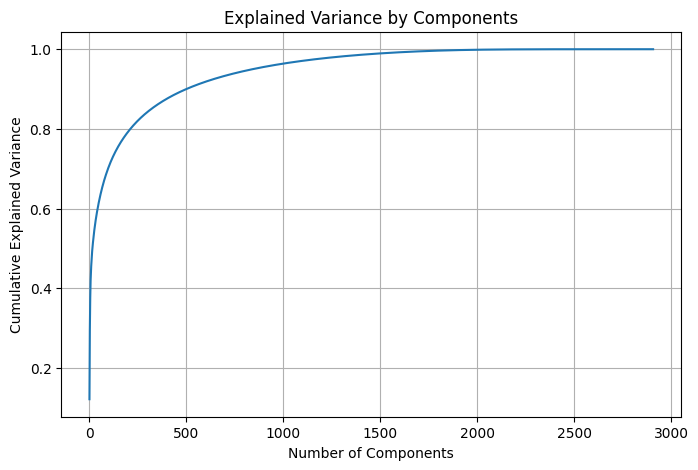

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

anomaly_data = train_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']).copy()

feat_names = anomaly_data.columns

# features_scaled = scaler.fit_transform(anomaly_data)  # your feature columns


# Assuming tfidf_matrix is your feature matrix
pca = PCA().fit(anomaly_data)

# Plotting the cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.grid(True)
plt.show()

# # Determine the number of components to use based on the plot
# n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) > 0.85) + 1  # e.g., 85% variance

# # Now fit PCA with the determined optimal number of components
# pca_optimal = PCA(n_components=n_components)
# pca_features_optimal = pca_optimal.fit_transform(tfidf_matrix.toarray())


In [36]:

# from sklearn.ensemble import IsolationForest


# iso_forest_best = IsolationForest(bootstrap=True, contamination=0.2, max_samples='auto',
#                 n_estimators=10, max_features=1, random_state=42)

# # Fit the model to the training data
# iso_forest_best.fit(anomaly_data)

# # Predict anomalies (outliers)
# train_anomalies = iso_forest_best.predict(anomaly_data)



# # save iso_forest_best model

# import dill

# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/iso_forest_best.pkl', 'wb') as f:

#     dill.dump(iso_forest_best, f)



In [38]:

# anamolies = pd.DataFrame()
# anamolies['anomaly'] = train_anomalies
# anamolies['target'] = train_merged['score']

# # Compare anomaly distribution to target classes
# anomaly_distribution = anamolies.groupby(['target', 'anomaly']).size().unstack(fill_value=0)
# print(anomaly_distribution)

In [37]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Plot the distribution of anomalies across different classes
# plt.figure(figsize=(10, 6))
# sns.countplot(x='target', hue='anomaly', data=anamolies)
# plt.title('Distribution of Anomalies Across Target Classes')
# plt.xlabel('Target Class')
# plt.ylabel('Count')
# plt.legend(title='Anomaly', labels=['Anomaly', 'Normal'])
# plt.show()

In [41]:
# Scale features

# Applying PCA
pca = PCA(n_components=1000)  # Reduce to 50 dimensions

pca_features_train = pca.fit_transform(train_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))

pca_features_val = pca.transform(validation_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))

pca_features_test = pca.transform(test_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))

# Applying t-SNE
tsne = TSNE(n_components=5, learning_rate='auto', init='random')  # Reduce to 2 dimensions

tsne_features_train = tsne.fit_transform(pca_features_train)  # It's common to apply t-SNE after PCA

tsne_features_val = tsne.transform(pca_features_val)

tsne_features_test = tsne.transform(pca_features_test)


# Add reduced features to DataFrame

for i in range(pca_features_train.shape[1]):
    train_merged[f'pca_feature{i+1}'] = pca_features_train[:, i]
    validation_merged[f'pca_feature{i+1}'] = pca_features_val[:, i]
    test_merged[f'pca_feature{i+1}'] = pca_features_test[:, i]


    
train_merged['tsne_feature1'], train_merged['tsne_feature2'] = tsne_features_train[:, 0], tsne_features_train[:, 1], tsne_features_train[:, 2], tsne_features_train[:, 3], tsne_features_train[:, 4]

validation_merged['tsne_feature1'], validation_merged['tsne_feature2'] = tsne_features_val[:, 0], tsne_features_val[:, 1], tsne_features_val[:, 2], tsne_features_val[:, 3], tsne_features_val[:, 4]

test_merged['tsne_feature1'], test_merged['tsne_feature2'] = tsne_features_test[:, 0], tsne_features_test[:, 1], tsne_features_test[:, 2], tsne_features_test[:, 3], tsne_features_test[:, 4]



# save pca and tsne models

with open('/home/jack/github/kaggle/scoring/model_data/sklearn/pca_model.pkl', 'wb') as f:

    dill.dump(pca, f)

with open('/home/jack/github/kaggle/scoring/model_data/sklearn/tsne_model.pkl', 'wb') as f:

    dill.dump(tsne, f)




ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- pos_$
- pos_''
- pos_,
- pos_-LRB-
- pos_-RRB-
- ...


In [ ]:
df['score'] = df['score'] - 1

df['score'].value_counts()

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

anomaly_data = df.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']).copy()

features_scaled = scaler.fit_transform(anomaly_data)  # your feature columns

# Cluster the data
kmeans = KMeans(n_clusters=6, random_state=42)

# df['clusters'] = kmeans.fit_predict(pca_features)

df['clusters'] = kmeans.fit_predict(features_scaled)

# Calculate metrics
ari_score = adjusted_rand_score(df['score'], df['clusters'])

nmi_score = normalized_mutual_info_score(df['score'], df['clusters'])

print(f"Adjusted Rand Index: {ari_score:.4f}")
print(f"Normalized Mutual Information: {nmi_score:.4f}")


In [ ]:
import seaborn as sns
sns.countplot(x='clusters', hue='score', data=df)

In [ ]:
from sklearn.ensemble import IsolationForest

# Fit an Isolation Forest for each cluster using PCA features

for cluster in df['clusters'].unique():
    subset = df[df['clusters'] == cluster]
    iforest = IsolationForest(n_estimators=100, contamination='auto')
    anomaly_scores = iforest.fit_predict(subset[[f'pca_feature{i+1}' for i in range(2000)]])  # Using first 50 PCA components
    df.loc[df['clusters'] == cluster, 'pca_anomaly_score'] = anomaly_scores

# Normalize the anomaly scores based on cluster frequencies

cluster_frequencies = df['clusters'].value_counts(normalize=True)

def adjust_anomaly_score(row, score_type):
    frequency = cluster_frequencies[row['clusters']]
    return row[score_type] * (1 / frequency)

df['adjusted_pca_anomaly_score'] = df.apply(lambda row: adjust_anomaly_score(row, 'pca_anomaly_score'), axis=1)

# df['adjusted_tsne_anomaly_score'] = df.apply(lambda row: adjust_anomaly_score(row, 'tsne_anomaly_score'), axis=1)

# save class frequencies to file

cluster_frequencies.to_csv('/home/jack/github/kaggle/scoring/model_data/sklearn/class_frequencies.csv')


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Calculate local density using PCA features
nn = NearestNeighbors(n_neighbors=3)
nn.fit(df[[f'pca_feature{i+1}' for i in range(2000)]])
distances, _ = nn.kneighbors(df[[f'pca_feature{i+1}' for i in range(2000)]])
df['local_density'] = 1 / distances.mean(axis=1)

In [ ]:
df.head()

In [ ]:
# # Import necessary libraries
# import pandas as pd
# from itertools import combinations

# # Assuming the DataFrame `df` and `score` are already defined
# # and excluding irrelevant columns

# # Calculate correlations with the target

# cor = df.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered' , 'score'], axis=1) # ,'processed_docs', 'topics',

# correlations = cor.corrwith(df['score']).sort_values(ascending=False)



# # Set a correlation threshold or select top N features
# correlation_threshold = 0.3

# top_features = correlations[abs(correlations) > correlation_threshold].index.tolist()

# # Print the most correlated features
# print("Top correlations with the score:")
# print(top_features)

# # Generate interaction terms between pairs of top features
# for feature1, feature2 in combinations(top_features, 2):
#     df[f'interaction_{feature1}_{feature2}'] = df[feature1] * df[feature2]


# # Optional: print the list of created interaction terms
# interaction_terms = [f'interaction_{feature1}_{feature2}' for feature1, feature2 in combinations(top_features, 2)]
# print("Created interaction terms:")
# print(interaction_terms)


# # export top_features to text file

# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/top_corelations.txt', 'w') as f:
#     for item in top_features:
#         f.write("%s\n" % item)


In [ ]:
train = df.copy()

In [ ]:
train.head()

In [ ]:
# train.to_csv('/home/jack/github/kaggle/scoring/data/train_full.csv', index=False)

# import pandas as pd
# train = pd.read_csv('/home/jack/github/kaggle/scoring/data/train_full.csv')

In [ ]:
train.head()

In [ ]:
len(train.columns)

In [ ]:
train.score.value_counts()

In [ ]:
# import gc

# del df_train_final, df, df_ngrams, df_svd, df_pos, df_entities, df_deps, pos_df, ner_df, dep_df, pos_features, ner_features, dep_features

# gc.collect()

In [ ]:
# show columns with nan values greater than 0

nan_cols = train.isna().sum()

nan_cols = nan_cols[nan_cols > 0]

nan_cols    


In [ ]:
# drop_cols = ['full_text', 'clean_text', 'lowered']   # processed_docs', , 'global_coherence', 'topics'


# train_df = train.copy()

# train_df.drop(columns=drop_cols, inplace= True)


# from sklearn.model_selection import train_test_split

# # Features and target variable
# X = train_df.drop('score', axis=1)
# y = train_df['score']

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
feature_cols = []

for col in X_train.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 

In [ ]:
# pd.set_option('display.max_columns', None)
# feature_cols

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np

# Extract labels from the training and validation datasets
train_labels = y_train.copy()
val_labels = y_test.copy()

# Extract features for scaling
train_features = X_train[feature_cols] # Subset with only feature columns
val_features = X_test[feature_cols]

# Initialize the scaler
scaler = StandardScaler()  # Using StandardScaler for scaling

# Fit the scaler to the training features
scaler.fit(train_features)  # This defines the transformation based on the training data

# Transform training and validation features
train_feats_scaled = scaler.transform(train_features)  # Transforms the training data
val_feats_scaled = scaler.transform(val_features)  # Transforms the validation data

# Reassign the scaled features to the original DataFrames, keeping the same column names
X_train[feature_cols] = train_feats_scaled  # Replace the original features with scaled ones
X_test[feature_cols] = val_feats_scaled



# Save the scaler for later use
with open(file_config['scaler'], 'wb') as f:
    pickle.dump(scaler, f)  # Persist the scaler for future use or reference


In [ ]:
print(X_train.shape, X_test.shape)

In [ ]:
X_train.head()

In [ ]:
y_train.head()

In [ ]:
print(X_train.shape, y_train.shape)

In [ ]:
# feature_cols.append('anomaly')

# save the order of the column names to a txt file

with open(file_config['feature_cols'], 'w') as f:
    for item in feature_cols:
        f.write("%s\n" % item)

In [ ]:
# Check if the file has been written correctly and is not empty
import os

scaler_path = file_config['scaler']

if os.path.getsize(scaler_path) > 0:

    print(f"Scaler saved successfully in {scaler_path}.")
    
else:

    print(f"Failed to save scaler to {scaler_path}. File is empty.")

In [ ]:
# Check if the scaler is StandardScaler
if isinstance(scaler, StandardScaler):
    print("The scaler is a StandardScaler.")
elif isinstance(scaler, MinMaxScaler):
    print("The scaler is a MinMaxScaler.")
else:
    print("The scaler is neither StandardScaler nor MinMaxScaler.")

In [ ]:
# To convert features and targets to NumPy arrays for ML use

# train_features = X_train.values

# train_labels = np.array(train_labels.values)

# val_features = X_test.values

# val_labels = np.array(y_test.values)




# print("Features shape:", train_features.shape)
# print("Target shape:", train_labels.shape)

# print("Features shape:", val_features.shape)
# print("Target shape:", val_labels.shape)



#####     Features shape: (3, 1389)


In [ ]:
import pandas as pd
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn import ensemble, model_selection, metrics
import numpy as np
import pickle
import os
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score
import keras_tuner

# Function to compute Quadratic Weighted Kappa
def quadratic_weighted_kappa_scorer(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

# Define the model building function for the tuner
def build_model(hp):
    model_type = hp.Choice('model_type', ['random_forest', 'gradient_boosting', 'lightgbm'])
    if model_type == 'random_forest':
        model = ensemble.RandomForestClassifier(
            n_estimators=hp.Int('n_estimators', 10, 100, step=10),
            max_depth=hp.Int('max_depth', 3, 20),
            min_samples_split=hp.Int('min_samples_split', 2, 20),
            min_samples_leaf=hp.Int('min_samples_leaf', 1, 10),
            criterion=hp.Choice('criterion', ['gini', 'entropy']),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_subsample']),
            max_samples=hp.Float('max_samples', 0.1, 1.0, sampling='log'))
    elif model_type == 'gradient_boosting':
        model = ensemble.GradientBoostingClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            max_depth=hp.Int('max_depth', 3, 15),
            subsample=hp.Float('subsample', 0.5, 1.0, step=0.1))
    else:  # LightGBM
        from lightgbm import LGBMClassifier
        model = LGBMClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            num_leaves=hp.Int('num_leaves', 31, 127, step=16),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            min_child_samples=hp.Int('min_child_samples', 10, 50, step=10),
            max_depth=hp.Int('max_depth', 3, 15),  # Tunable max_depth parameter
            min_data_in_leaf=hp.Int('min_data_in_leaf', 20, 100, step=10),  # Increases the minimum data per leaf
            min_gain_to_split=hp.Float('min_gain_to_split', 0.001, 0.1, sampling='log'),  # Ensures splits bring gains
            lambda_l1=hp.Float('lambda_l1', 0.01, 10.0, sampling='log'),  # L1 regularization
            lambda_l2=hp.Float('lambda_l2', 0.01, 10.0, sampling='log'),  # L2 regularization
            force_col_wise=True,  # Force using column-wise calculation to avoid overhead
            class_weight='balanced'  # Handling class imbalance
        )
    return model





# Prepare data: Assuming X_train and y_train are already defined
X_train_original = X_train.drop(columns='essay_id').copy()  # Keep the original training data
y_train_original = y_train.drop(columns='essay_id').copy() 

# Apply SMOTE to balance the minority classes
smote = SMOTE(sampling_strategy='not minority', random_state=42)
X_train_upsampled, y_train_upsampled = smote.fit_resample(X_train_original, y_train_original)


In [ ]:
# Tuner configuration
tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=12),
    hypermodel=build_model,
    scoring=make_scorer(quadratic_weighted_kappa_scorer),
    cv=model_selection.StratifiedKFold(5),
    directory='.',
    project_name='data/sklearn',
    overwrite=True)


# Tuning on the original data

tuner.search(X_train_original.values, y_train_original.values)

# tuner.search(X_train_upsampled.values, y_train_upsampled.values)


In [ ]:
# # apply smote within k-fold cross validation in order to avoid data leakage

# # Define the cross-validation strategy

# cv = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Initialize the model
# model = ensemble.RandomForestClassifier(random_state=42)

# # Initialize the SMOTE object

# smote = SMOTE(sampling_strategy='not majority', random_state=42)

# # Initialize the StandardScaler
# scaler = StandardScaler()

# # Initialize the list to store the cross-validated scores

# cv_scores = []

# # Perform cross-validation

# for train_idx, val_idx in cv.split(X_train, y_train):

#     # Extract the training and validation data
#     X_train_fold, y_train_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]

#     # Apply SMOTE to the training data
#     X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fold, y_train_fold)

#     # Scale the training and validation data
#     X_train_scaled = scaler.fit_transform(X_train_resampled)
#     X_val_scaled = scaler.transform(X_val_fold)

#     # Fit the model on the training data
#     model.fit(X_train_scaled, y_train_resampled)

#     # Predict the target on the validation data
#     y_pred = model.predict(X_val_scaled)

#     # Compute the Quadratic Weighted Kappa
#     qwk = quadratic_weighted_kappa_scorer(y_val_fold, y_pred)

#     # Append the score to the list
#     cv_scores.append(qwk)

# # Compute the average score

# cv_score = np.mean(cv_scores)

# # Print the average score

# print(f"Average Quadratic Weighted Kappa: {cv_score:.4f}")

# # Save the model

# with open(file_config['sklearn_model'], 'wb') as f:
#     pickle.dump(model, f)



In [ ]:
# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]

# # Fit models on both upsampled and original data
# model_standard = clone(best_model)
# model_standard.fit(X_train_original, y_train_original)

# model_upsampled = clone(best_model)
# model_upsampled.fit(X_train_upsampled, y_train_upsampled)

# # Ensemble using voting
# ensemble_model = VotingClassifier(estimators=[
#     ('standard', model_standard),
#     ('upsampled', model_upsampled)
# ], voting='soft')



In [ ]:
# Assuming X_val and y_val are your validation sets

best_model.fit(X_train_original, y_train_original)  # Optionally refit if necessary

# ensemble_model.fit(X_train_original, y_train_original)  # Optionally refit if necessary

In [ ]:
# ensamble_predictions = ensemble_model.predict(X_test.drop(columns=['essay_id']))

# # Evaluate and print results
# print("Validation Accuracy:", accuracy_score(y_test, ensamble_predictions))
# print("Validation Cohen's Kappa:", quadratic_weighted_kappa_scorer(y_test, ensamble_predictions))
# print("Validation Quadratic Weighted Kappa:", quadratic_weighted_kappa_scorer(y_test, ensamble_predictions))
# print("Validation Cohens Weighted Kappa:",cohen_kappa_score(y_test, ensamble_predictions, weights='quadratic'))

In [ ]:
predictions = best_model.predict(X_test.drop(columns=['essay_id']))

# Evaluate and print results
print("Validation Accuracy:", accuracy_score(y_test, predictions))
print("Validation Cohen's Kappa:", quadratic_weighted_kappa_scorer(y_test, predictions))
print("Validation Quadratic Weighted Kappa:", quadratic_weighted_kappa_scorer(y_test, predictions))
print("Validation Cohens Weighted Kappa:",cohen_kappa_score(y_test, predictions, weights='quadratic'))

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

In [ ]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

In [ ]:
from joblib import dump, load

dump(best_model, file_config['sklearn_model'])


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_test, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# X_test['predictions'] = predictions

# df_aggregated = X_test.groupby('essay_id')['predictions'].agg(lambda x: x.value_counts().index[0]).reset_index()

# df_aggregated.head()

In [ ]:
# import tensorflow_hub as hub
# import tensorflow as tf
# import os

# # Define the local path where the model will be saved
# model_dir = '/home/jack/github/kaggle/scoring/data/directory'

# # Ensure the directory exists
# os.makedirs(model_dir, exist_ok=True)

# # Download and save the model
# use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
# tf.saved_model.save(use_model, model_dir)


In [ ]:
# get number of features from the model

# Get the number of features from the model

best_model = load(file_config['sklearn_model'])

# Get the number of features from the model

num_features = len(best_model.feature_importances_)

# Print the number of features

print(f"Number of features: {num_features}")

In [ ]:
# Identifying misclassified samples
misclassified_indices = (y_true != predictions)
misclassified_samples = val_features[misclassified_indices]
misclassified_true_labels = y_true[misclassified_indices]
misclassified_predicted_labels = predictions[misclassified_indices]


In [ ]:
# Examining features of misclassified samples
import pandas as pd
misclassified_df = pd.DataFrame(misclassified_samples)
misclassified_df['True_Label'] = misclassified_true_labels
misclassified_df['Predicted_Label'] = misclassified_predicted_labels
# Display the first few rows of the misclassified samples
misclassified_df.head()

In [ ]:
# # Feature importance from LightGBM
# feature_importance = best_model.feature_importance(importance_type='gain')
# feature_names = val_features.columns
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# # Sort features by importance
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)


In [ ]:
# Checking class distribution in the true labels
label_counts = pd.Series(y_true).value_counts()
print(label_counts)


In [ ]:
# from sklearn.model_selection import GridSearchCV
# # Define the hyperparameters to tune
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'num_leaves': [31, 62, 128],
#     'n_estimators': [50, 100, 200]
# }
# grid_search = GridSearchCV(best_model, param_grid, scoring='', cv=5)
# grid_search.fit(val_features, val_labels)
# print("Best parameters:", grid_search.best_params_)


In [ ]:
# Check LightGBM version
import lightgbm as lgb
print(lgb.__version__)


In [ ]:
# # Ensure the model is fitted
# if not hasattr(best_model, 'feature_importance_'):
#     best_model.fit(val_features, val_labels)  # Train or re-train the model

# # Retrieve feature importance
# feature_importance = best_model.feature_importance_  # Underscore at the end
# feature_names = val_features.columns

# # Create DataFrame for feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print(feature_importance_df)


In [ ]:
# Assuming `df` is the original DataFrame and `predictions` is a list/array of predicted labels
# If there's a subset used for predictions, ensure it aligns with the DataFrame
val_df['Predicted_Label'] = predictions


In [ ]:
print(len(val_features), len(val_df), len(predictions))

In [ ]:
val_df.tail()

In [ ]:
# merge 'clean_text' column back with val df 

text = val_essays[['essay_id', 'clean_text']]

val_df = val_df.merge(text, on = 'essay_id')

val_df.head()

In [ ]:
# Assuming `df` has the original labels in a column named 'True_Label'
misclassified_samples = val_df[val_df['score'] != val_df['Predicted_Label']]

# Display misclassified samples
print(misclassified_samples[['score', 'Predicted_Label', 'clean_text']][:15])


In [ ]:
# Example: Analyze original text of misclassified samples
misclassified_text = misclassified_samples['clean_text']  # Assuming 'Text' is the original text data
print(misclassified_text.head())


In [ ]:
# load tf model
len(misclassified_text)

In [ ]:
# add full mis classified text to a txt file seperated by  '---' and a new line after every 10 words in each essay

with open('misclassified_text.txt', 'w') as f:
    for essay in misclassified_text:
        f.write("%s\n" % essay)
        f.write('---\n')
        


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming `df` has your model's features and labels
X = val_df[feature_cols]
y = val_df['score'] == val_df['Predicted_Label']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a RandomForest to see feature importances
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Get the most important features
importances = clf.feature_importances_
features = feature_cols
important_features = {features[i]: importances[i] for i in range(len(features))}

# convert to percentages rounded and sort

important_features = {k: round(v, 5) for k, v in important_features.items()}

print("Most predictive features of misclassification:", sorted(important_features.items(), key=lambda x: x[1], reverse=True))

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assume val_df and feature_cols are already defined

# # Set the option to display all rows
# pd.set_option('display.max_rows', None)

# # Selecting the features and the target
# X = val_df[feature_cols]
# y = val_df['score']

# # Calculate the correlation between features and the target
# corr = X.corrwith(y)

# # Sort the correlation values
# corr = corr.sort_values(ascending=False)

# # Convert the Series to a DataFrame for heatmap compatibility
# corr_df = pd.DataFrame(corr, columns=['Correlation'])

# corr_df


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # Define the feature set with and without the specific features
# X_with = val_df[feature_cols]  # including all features
# X_without = val_df.drop(columns=['misspelling_count', 'sentence_length'], axis=1) # excluding problematic features

# y = val_df['score']  # target variable

# # Split the data
# X_train_with, X_test_with, y_train, y_test = train_test_split(X_with, y, test_size=0.3, random_state=42)
# X_train_without, X_test_without, _ , _ = train_test_split(X_without, y, test_size=0.3, random_state=42)

# # Train models
# model_with = RandomForestClassifier().fit(X_train_with, y_train)
# model_without = RandomForestClassifier().fit(X_train_without, y_train)

# # Evaluate models
# print("With features:")
# print(classification_report(y_test, model_with.predict(X_test_with)))

# print("Without features:")
# print(classification_report(y_test, model_without.predict(X_test_without)))
